In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [1]:
import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [3]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

In [4]:
train.shape

(2000, 8)

In [64]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [65]:
train.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [66]:
train.duplicated().sum()

np.int64(0)

In [67]:
#Class Distribution
train["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

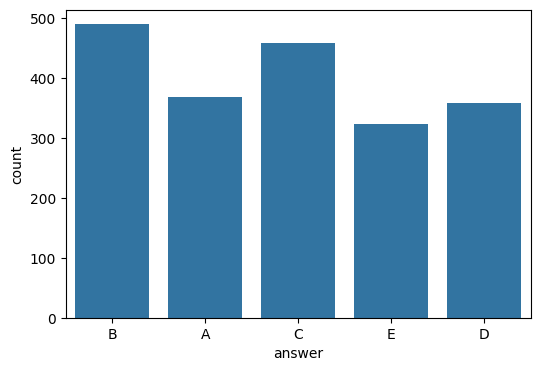

In [68]:
#class distribution plot
plt.figure(figsize=(6,4))

sns.countplot(x="answer",data=train)

plt.show()

In [69]:
#prompt length
train["prompt_length"] = train["prompt"].apply(len)

In [70]:
train["prompt_length"].describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_length, dtype: float64

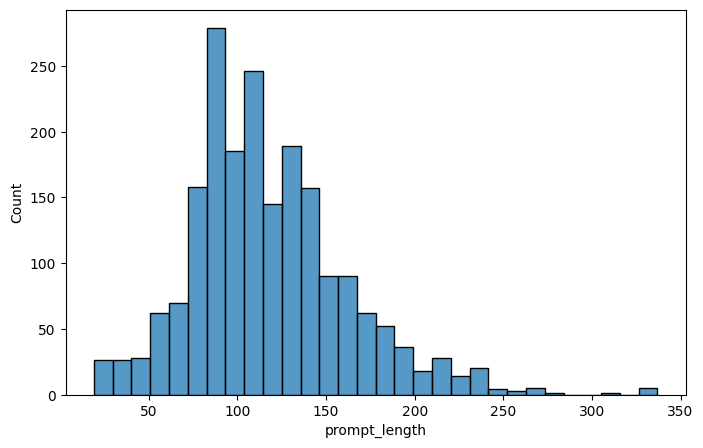

In [71]:
plt.figure(figsize=(8,5))

sns.histplot(train["prompt_length"],bins=30)

plt.show()

In [72]:
train.iloc[0]

id                                                               1
prompt           Pick the best possible answer: What is Martin ...
A                Martin Heidegger believes that humans exist wi...
B                Martin Heidegger believes that humans do not e...
C                Martin Heidegger does not believe in the exist...
D                Martin Heidegger believes that the relationshi...
E                Martin Heidegger believes that time is an illu...
answer                                                           B
prompt_length                                                  142
Name: 0, dtype: object

In [73]:
# Calculate length of each option

for col in ["A", "B", "C", "D", "E"]:
    train[f"{col}_length"] = train[col].astype(str).apply(len)

In [74]:
option_length_stats = train[
    ["A_length", "B_length", "C_length", "D_length", "E_length"]
].describe()

display(option_length_stats)

,A_length,B_length,C_length,D_length,E_length
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,164.091500,166.616500,167.227000,162.56350,164.230000
std,105.677145,113.829917,105.723674,104.11657,107.777712
min,1.000000,2.000000,2.000000,1.00000,2.000000
25%,86.000000,82.000000,88.000000,91.00000,84.000000
50%,143.000000,151.000000,158.000000,141.00000,144.000000
75%,234.000000,222.000000,224.000000,231.00000,224.000000
max,472.000000,662.000000,530.000000,450.00000,587.000000


In [75]:
#Class Percentages
answer_percentage = (
    train["answer"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

display(answer_percentage)

answer
A    18.45
B    24.50
C    22.95
D    17.90
E    16.20
Name: proportion, dtype: float64

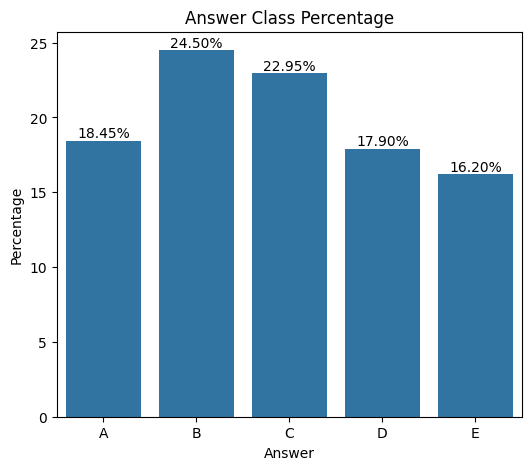

In [76]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=answer_percentage.index,
    y=answer_percentage.values
)

plt.title("Answer Class Percentage")
plt.xlabel("Answer")
plt.ylabel("Percentage")

for i, value in enumerate(answer_percentage.values):
    ax.text(i, value+0.2, f"{value:.2f}%", ha="center")

plt.show()

## EDA Observations

- Dataset contains approximately 2000 training samples and 500 test samples.
- No missing values or duplicate rows were observed.
- The answer classes (A–E) are nearly balanced, reducing the risk of class bias.
- Prompt lengths vary but most questions fall within a moderate character range.
- Option lengths are fairly consistent across all five choices, suggesting no significant length-based bias.
- The dataset appears clean and suitable for training without extensive preprocessing.

In [77]:
# Convert MCQs into binary samples
option_columns = ["A", "B", "C", "D", "E"]

train_samples = []

for _, row in train.iterrows():

    question = str(row["prompt"])

    correct = row["answer"]

    for option in option_columns:

        train_samples.append({

            "text": question + " [SEP] " + str(row[option]),

            "label": 1 if option == correct else 0,

            "option": option

        })

binary_train = pd.DataFrame(train_samples)

binary_train.head()

,text,label,option
0,Pick the best possible answer: What is Martin ...,0,A
1,Pick the best possible answer: What is Martin ...,1,B
2,Pick the best possible answer: What is Martin ...,0,C
3,Pick the best possible answer: What is Martin ...,0,D
4,Pick the best possible answer: What is Martin ...,0,E


In [78]:
binary_train.shape

(10000, 3)

In [79]:
binary_train["label"].value_counts()

label
0    8000
1    2000
Name: count, dtype: int64

In [80]:
from sklearn.model_selection import train_test_split

# Keep original MCQ split for evaluation
train_original, val_original = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train["answer"]
)

# Convert original train MCQs into binary samples
train_samples = []

for _, row in train_original.iterrows():

    question = str(row["prompt"])
    correct = row["answer"]

    for option in option_columns:

        train_samples.append({
            "text": question + " [SEP] " + str(row[option]),
            "label": 1 if option == correct else 0,
            "option": option
        })

train_df = pd.DataFrame(train_samples)

# Convert original validation MCQs into binary samples
val_samples = []

for _, row in val_original.iterrows():

    question = str(row["prompt"])
    correct = row["answer"]

    for option in option_columns:

        val_samples.append({
            "text": question + " [SEP] " + str(row[option]),
            "label": 1 if option == correct else 0,
            "option": option
        })

val_df = pd.DataFrame(val_samples)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Original Validation:", val_original.shape)

Train: (8000, 3)
Validation: (2000, 3)
Original Validation: (400, 14)


In [81]:
# TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

MAX_FEATURES = 5000

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=MAX_FEATURES,
    ngram_range=(1,2)
)

X_train = vectorizer.fit_transform(train_df["text"])

X_val = vectorizer.transform(val_df["text"])

y_train = train_df["label"].values
y_val = val_df["label"].values

print(X_train.shape)
print(X_val.shape)

(8000, 5000)
(2000, 5000)


In [106]:
import torch
import torch.nn as nn

# Already tensors
X_train = X_train.float()
X_val = X_val.float()

# CrossEntropyLoss requires Long labels
y_train = y_train.long()
y_val = y_val.long()

print(X_train.shape)
print(X_val.shape)
print(X_train.dtype)
print(y_train.dtype)

torch.Size([8000, 5000])
torch.Size([2000, 5000])
torch.float32
torch.int64


In [108]:
#TensorDataset
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

In [109]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [110]:
batch = next(iter(train_loader))

print(batch[0].shape)
print(batch[1].shape)

torch.Size([64, 5000])
torch.Size([64])


**Model 1**

In [111]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [112]:
import torch
import torch.nn as nn

class DeepFFNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(256,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64,2)
        )

    def forward(self,x):
        return self.model(x)

In [113]:
INPUT_DIM = X_train.shape[1]

model = DeepFFNN(INPUT_DIM).to(device)

print(model)

!pip install -q wandb

import wandb

wandb.login()

wandb.init(
    project="Smart-MCQ-Solver",
    name="DeepFFNN-TFIDF",
    config={
        "epochs": 15,
        "batch_size": 64,
        "learning_rate": 2e-3,
        "optimizer": "AdamW",
        "architecture": "DeepFFNN",
        "dropout": [0.35,0.30,0.20],
        "max_features":15000
    }
)

DeepFFNN(
  (model): Sequential(
    (0): Linear(in_features=5000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=2, bias=True)
  )
)


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▃▅▆▇▇▇▇▇▇█████
train_f1,▁▅▆▇▇▇▇████████
train_loss,█▅▄▃▂▂▂▂▂▁▁▁▁▁▁
validation_accuracy,▁▄▅▆▇▇▇▇▇██████
validation_f1,▁▆▇▇▇▇▇▇███████
validation_loss,█▅▄▃▂▂▂▂▂▁▁▁▁▁▁
epoch,15
learning_rate,0.002
train_accuracy,0.94225


In [114]:
from sklearn.metrics import accuracy_score,f1_score
import numpy as np

def train_one_epoch(model,loader,optimizer,criterion):

    model.train()

    total_loss=0

    preds=[]
    labels=[]

    for X_batch,y_batch in loader:

        X_batch=X_batch.to(device)

        y_batch=y_batch.long().to(device)

        optimizer.zero_grad()

        outputs=model(X_batch)

        loss=criterion(outputs,y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

        optimizer.step()

        total_loss+=loss.item()

        prediction=torch.argmax(outputs,dim=1)

        preds.extend(prediction.cpu().numpy())

        labels.extend(y_batch.cpu().numpy())

    return (
        total_loss/len(loader),
        accuracy_score(labels,preds),
        f1_score(labels,preds)
    )


def validate(model,loader,criterion):

    model.eval()

    total_loss=0

    preds=[]
    labels=[]

    with torch.no_grad():

        for X_batch,y_batch in loader:

            X_batch=X_batch.to(device)

            y_batch=y_batch.long().to(device)

            outputs=model(X_batch)

            loss=criterion(outputs,y_batch)

            total_loss+=loss.item()

            prediction=torch.argmax(outputs,dim=1)

            preds.extend(prediction.cpu().numpy())

            labels.extend(y_batch.cpu().numpy())

    return (
        total_loss/len(loader),
        accuracy_score(labels,preds),
        f1_score(labels,preds)
    )

In [115]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.05
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [116]:
EPOCHS = 15

best_val_f1 = 0

patience = 5

counter = 0

history = {
    "train_loss":[],
    "val_loss":[],
    "train_acc":[],
    "val_acc":[],
    "train_f1":[],
    "val_f1":[]
}

for epoch in range(EPOCHS):

    train_loss,train_acc,train_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss,val_acc,val_f1 = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    wandb.log({

        "epoch":epoch+1,

        "train_loss":train_loss,
        "validation_loss":val_loss,

        "train_accuracy":train_acc,
        "validation_accuracy":val_acc,

        "train_f1":train_f1,
        "validation_f1":val_f1,

        "learning_rate":optimizer.param_groups[0]["lr"]

    })

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Acc    : {val_acc:.4f}")

    print(f"Train F1   : {train_f1:.4f}")

    print(f"Val F1     : {val_f1:.4f}")

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        counter = 0

        torch.save(
            model.state_dict(),
            "model1_ffnn.pth"
        )

        print("Best model saved.")

    else:

        counter += 1

        if counter >= patience:

            print("Early stopping.")

            break

print("\nTraining Complete")

print("Best Validation F1:",best_val_f1)


Epoch 1/15
Train Loss : 0.5302
Val Loss   : 0.4366
Train Acc  : 0.7855
Val Acc    : 0.8270
Train F1   : 0.0872
Val F1     : 0.2822
Best model saved.

Epoch 2/15
Train Loss : 0.4162
Val Loss   : 0.3565
Train Acc  : 0.8438
Val Acc    : 0.8690
Train F1   : 0.4635
Val F1     : 0.6006
Best model saved.

Epoch 3/15
Train Loss : 0.3470
Val Loss   : 0.3041
Train Acc  : 0.8808
Val Acc    : 0.9060
Train F1   : 0.6397
Val F1     : 0.7063
Best model saved.

Epoch 4/15
Train Loss : 0.3094
Val Loss   : 0.2875
Train Acc  : 0.8999
Val Acc    : 0.9080
Train F1   : 0.7041
Val F1     : 0.7278
Best model saved.

Epoch 5/15
Train Loss : 0.2924
Val Loss   : 0.2764
Train Acc  : 0.9090
Val Acc    : 0.9200
Train F1   : 0.7345
Val F1     : 0.7640
Best model saved.

Epoch 6/15
Train Loss : 0.2713
Val Loss   : 0.2679
Train Acc  : 0.9174
Val Acc    : 0.9145
Train F1   : 0.7606
Val F1     : 0.7482

Epoch 7/15
Train Loss : 0.2612
Val Loss   : 0.2383
Train Acc  : 0.9227
Val Acc    : 0.9280
Train F1   : 0.7801
Val F1

In [117]:
import joblib

joblib.dump(
    vectorizer,
    "/kaggle/working/tfidf_vectorizer.pkl"
)

print("Vectorizer Saved")

Vectorizer Saved


In [118]:
model.load_state_dict(
    torch.load(
        "model1_ffnn.pth",
        map_location=device
    )
)

model.eval()

DeepFFNN(
  (model): Sequential(
    (0): Linear(in_features=5000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [119]:
option_columns = ["A","B","C","D","E"]

test_samples=[]

for _,row in test.iterrows():

    question=str(row["prompt"])

    for option in option_columns:

        test_samples.append({

            "id":row["id"],

            "option":option,

            "text":question+" [SEP] "+str(row[option])

        })

test_binary=pd.DataFrame(test_samples)

print(test_binary.shape)

test_binary.head()

(2500, 3)


,id,option,text
0,1,A,Pick the best possible answer: What is the rel...
1,1,B,Pick the best possible answer: What is the rel...
2,1,C,Pick the best possible answer: What is the rel...
3,1,D,Pick the best possible answer: What is the rel...
4,1,E,Pick the best possible answer: What is the rel...


In [120]:
# Transform test data using the trained TF-IDF vectorizer

X_test = vectorizer.transform(test_binary["text"])

X_test = torch.tensor(
    X_test.toarray(),
    dtype=torch.float32
)

test_dataset = torch.utils.data.TensorDataset(X_test)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

print(X_test.shape)

torch.Size([2500, 5000])


In [121]:
import torch.nn.functional as F

model.eval()

all_scores = []

with torch.no_grad():

    for (X_batch,) in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        probs = F.softmax(outputs, dim=1)

        positive_probs = probs[:, 1]

        all_scores.extend(
            positive_probs.cpu().numpy()
        )

test_binary["score"] = all_scores

test_binary.head()

,id,option,text,score
0,1,A,Pick the best possible answer: What is the rel...,0.780532
1,1,B,Pick the best possible answer: What is the rel...,0.591885
2,1,C,Pick the best possible answer: What is the rel...,0.040159
3,1,D,Pick the best possible answer: What is the rel...,0.041895
4,1,E,Pick the best possible answer: What is the rel...,0.455990


In [122]:
submission = []

for question_id, group in test_binary.groupby("id"):

    ranked = (
        group
        .sort_values("score", ascending=False)
        .head(3)
    )

    prediction = " ".join(ranked["option"].tolist())

    submission.append({
        "id": question_id,
        "prediction": prediction
    })

submission = pd.DataFrame(submission)

submission.head()

,id,prediction
0,1,A B E
1,2,B A C
2,3,B C A
3,4,E B A
4,5,C A B


In [123]:
submission.to_csv(
    "/kaggle/working/submission_model1.csv",
    index=False
)

print(submission.head())

print("Saved to /kaggle/working/submission_model1.csv")

   id prediction
0   1      A B E
1   2      B A C
2   3      B C A
3   4      E B A
4   5      C A B
Saved to /kaggle/working/submission_model1.csv


**MODEL 2**

In [124]:
!pip install -q transformers

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score,f1_score

In [125]:
train_binary = []

option_columns = ["A","B","C","D","E"]

for _,row in train.iterrows():

    prompt = str(row["prompt"])

    correct = row["answer"]

    for option in option_columns:

        train_binary.append({

            "text":prompt+" [SEP] "+str(row[option]),

            "label":1 if option==correct else 0

        })

train_binary = pd.DataFrame(train_binary)

train_binary.head()

,text,label
0,Pick the best possible answer: What is Martin ...,0
1,Pick the best possible answer: What is Martin ...,1
2,Pick the best possible answer: What is Martin ...,0
3,Pick the best possible answer: What is Martin ...,0
4,Pick the best possible answer: What is Martin ...,0


In [126]:
train_df,val_df = train_test_split(

    train_binary,

    test_size=0.2,

    random_state=42,

    stratify=train_binary["label"]

)

print(train_df.shape)

print(val_df.shape)

(8000, 2)
(2000, 2)


In [127]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [128]:
class MCQDataset(Dataset):

    def __init__(self,df):

        self.texts = df["text"].tolist()

        self.labels = df["label"].tolist()

    def __len__(self):

        return len(self.texts)

    def __getitem__(self,idx):

        encoding = tokenizer(

            self.texts[idx],

            truncation=True,

            padding="max_length",

            max_length=128,

            return_tensors="pt"

        )

        return{

            "input_ids":encoding["input_ids"].squeeze(),

            "attention_mask":encoding["attention_mask"].squeeze(),

            "label":torch.tensor(

                self.labels[idx],

                dtype=torch.long

            )

        }

In [129]:
train_dataset = MCQDataset(train_df)

val_dataset = MCQDataset(val_df)

train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=64,

    shuffle=False

)

In [130]:
class TextCNN(nn.Module):

    def __init__(

        self,

        vocab_size,

        embed_dim=300,

        num_classes=2

    ):

        super().__init__()

        self.embedding = nn.Embedding(

            vocab_size,

            embed_dim

        )

        self.convs = nn.ModuleList([

            nn.Conv1d(

                embed_dim,

                128,

                kernel_size=3

            ),

            nn.Conv1d(

                embed_dim,

                128,

                kernel_size=4

            ),

            nn.Conv1d(

                embed_dim,

                128,

                kernel_size=5

            )

        ])

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(

            128*3,

            num_classes

        )

    def forward(

        self,

        input_ids,

        attention_mask=None

    ):

        x = self.embedding(input_ids)

        x = x.permute(0,2,1)

        pooled = []

        for conv in self.convs:

            c = F.relu(conv(x))

            c = F.max_pool1d(

                c,

                kernel_size=c.shape[2]

            ).squeeze(2)

            pooled.append(c)

        x = torch.cat(

            pooled,

            dim=1

        )

        x = self.dropout(x)

        return self.fc(x)

In [131]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

model = TextCNN(

    vocab_size=tokenizer.vocab_size

).to(device)

print(model)

TextCNN(
  (embedding): Embedding(30522, 300)
  (convs): ModuleList(
    (0): Conv1d(300, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(300, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(300, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=2, bias=True)
)


In [132]:
!pip install -q wandb

import wandb

wandb.login()

wandb.init(
    project="Smart-MCQ-Solver",
    name="TextCNN",
    config={
        "epochs":10,
        "batch_size":32,
        "learning_rate":2e-4,
        "optimizer":"AdamW",
        "architecture":"TextCNN"
    }
)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▄▅▆▆▇▇▇▇██████
train_f1,▁▄▆▇▇▇▇▇▇██████
train_loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁
validation_accuracy,▁▄▆▆▇▆▇▇███████
validation_f1,▁▅▆▇▇▇▇▇███████
validation_loss,█▅▄▃▃▃▂▂▂▁▁▁▁▁▁
epoch,15
learning_rate,0.002
train_accuracy,0.942


In [133]:
from sklearn.metrics import accuracy_score,f1_score

def train_one_epoch(model,loader,optimizer,criterion):

    model.train()

    running_loss = 0

    predictions = []
    labels = []

    for batch in loader:

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        y = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids,
            attention_mask
        )

        loss = criterion(outputs,y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs,dim=1)

        predictions.extend(
            preds.cpu().numpy()
        )

        labels.extend(
            y.cpu().numpy()
        )

    return (

        running_loss/len(loader),

        accuracy_score(labels,predictions),

        f1_score(labels,predictions)

    )

In [137]:
def validate(model,loader,criterion):

    model.eval()

    running_loss = 0

    predictions=[]

    labels=[]

    with torch.no_grad():

        for batch in loader:

            input_ids=batch["input_ids"].to(device)

            attention_mask=batch["attention_mask"].to(device)

            y=batch["label"].to(device)

            outputs=model(

                input_ids,

                attention_mask

            )

            loss=criterion(outputs,y)

            running_loss+=loss.item()

            preds=torch.argmax(outputs,dim=1)

            predictions.extend(

                preds.cpu().numpy()

            )

            labels.extend(

                y.cpu().numpy()

            )

    return(

        running_loss/len(loader),

        accuracy_score(labels,predictions),

        f1_score(labels,predictions)

    )

In [138]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.05
)

optimizer = optim.AdamW(

    model.parameters(),

    lr=2e-4,

    weight_decay=1e-4

)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=2

)

In [139]:
EPOCHS = 10

best_f1 = 0

patience = 3

counter = 0

history = {
    "train_loss":[],
    "val_loss":[],
    "train_acc":[],
    "val_acc":[],
    "train_f1":[],
    "val_f1":[]
}

for epoch in range(EPOCHS):

    train_loss,train_acc,train_f1 = train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion

    )

    val_loss,val_acc,val_f1 = validate(

        model,

        val_loader,

        criterion

    )

    scheduler.step(val_f1)

    wandb.log({

        "epoch":epoch+1,

        "train_loss":train_loss,

        "validation_loss":val_loss,

        "train_accuracy":train_acc,

        "validation_accuracy":val_acc,

        "train_f1":train_f1,

        "validation_f1":val_f1,

        "learning_rate":optimizer.param_groups[0]["lr"]

    })

    print("="*60)

    print(f"Epoch {epoch+1}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Train F1   : {train_f1:.4f}")

    print(f"Val F1     : {val_f1:.4f}")

    if val_f1 > best_f1:

        best_f1 = val_f1

        counter = 0

        torch.save(

            model.state_dict(),

            "textcnn_best.pth"

        )

        print("Best model saved.")

    else:

        counter += 1

        if counter >= patience:

            print("Early stopping.")

            break

print("Best Validation F1:",best_f1)

Epoch 1
Train Loss : 0.5391
Val Loss   : 0.3964
Train F1   : 0.2710
Val F1     : 0.3173
Best model saved.
Epoch 2
Train Loss : 0.4051
Val Loss   : 0.3203
Train F1   : 0.5308
Val F1     : 0.5699
Best model saved.
Epoch 3
Train Loss : 0.3300
Val Loss   : 0.2604
Train F1   : 0.6815
Val F1     : 0.7904
Best model saved.
Epoch 4
Train Loss : 0.2845
Val Loss   : 0.2456
Train F1   : 0.7681
Val F1     : 0.8000
Best model saved.
Epoch 5
Train Loss : 0.2545
Val Loss   : 0.1984
Train F1   : 0.8356
Val F1     : 0.9041
Best model saved.
Epoch 6
Train Loss : 0.2338
Val Loss   : 0.1820
Train F1   : 0.8598
Val F1     : 0.9296
Best model saved.
Epoch 7
Train Loss : 0.2165
Val Loss   : 0.1778
Train F1   : 0.8885
Val F1     : 0.9074
Epoch 8
Train Loss : 0.2004
Val Loss   : 0.1656
Train F1   : 0.9117
Val F1     : 0.9299
Best model saved.
Epoch 9
Train Loss : 0.1880
Val Loss   : 0.1547
Train F1   : 0.9297
Val F1     : 0.9597
Best model saved.
Epoch 10
Train Loss : 0.1850
Val Loss   : 0.1512
Train F1   : 0.

In [ ]:
model.load_state_dict(
    torch.load(
        "textcnn_best.pth",
        map_location=device
    )
)

model.eval()

TextCNN(
  (embedding): Embedding(30522, 300)
  (convs): ModuleList(
    (0): Conv1d(300, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(300, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(300, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=2, bias=True)
)

In [141]:
option_columns = ["A", "B", "C", "D", "E"]

test_samples = []

for _, row in test.iterrows():

    prompt = str(row["prompt"])

    for option in option_columns:

        test_samples.append({

            "id": row["id"],

            "option": option,

            "text": prompt + " [SEP] " + str(row[option])

        })

test_binary = pd.DataFrame(test_samples)

print(test_binary.shape)

test_binary.head()

(2500, 3)


,id,option,text
0,1,A,Pick the best possible answer: What is the rel...
1,1,B,Pick the best possible answer: What is the rel...
2,1,C,Pick the best possible answer: What is the rel...
3,1,D,Pick the best possible answer: What is the rel...
4,1,E,Pick the best possible answer: What is the rel...


In [142]:
class TestDataset(Dataset):

    def __init__(self, df):

        self.texts = df["text"].tolist()

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        encoding = tokenizer(

            self.texts[idx],

            truncation=True,

            padding="max_length",

            max_length=128,

            return_tensors="pt"

        )

        return {

            "input_ids": encoding["input_ids"].squeeze(),

            "attention_mask": encoding["attention_mask"].squeeze()

        }

In [143]:
test_dataset = TestDataset(test_binary)

test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False

)

In [144]:
import torch.nn.functional as F

model.eval()

scores = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        outputs = model(

            input_ids,

            attention_mask

        )

        probabilities = F.softmax(

            outputs,

            dim=1

        )

        positive_probability = probabilities[:,1]

        scores.extend(

            positive_probability.cpu().numpy()

        )

test_binary["score"] = scores

test_binary.head()

,id,option,text,score
0,1,A,Pick the best possible answer: What is the rel...,0.917858
1,1,B,Pick the best possible answer: What is the rel...,0.027972
2,1,C,Pick the best possible answer: What is the rel...,0.028420
3,1,D,Pick the best possible answer: What is the rel...,0.028906
4,1,E,Pick the best possible answer: What is the rel...,0.050920


In [145]:
submission = []

for question_id, group in test_binary.groupby("id"):

    ranked = group.sort_values(

        "score",

        ascending=False

    )

    prediction = " ".join(

        ranked.head(3)["option"].tolist()

    )

    submission.append({

        "id": question_id,

        "prediction": prediction

    })

submission = pd.DataFrame(submission)

submission.head()

,id,prediction
0,1,A E D
1,2,B E A
2,3,B E A
3,4,E D C
4,5,C A D


In [146]:
submission.to_csv(

    "submission_model2.csv",

    index=False

)

print(submission.head())

print("Saved successfully.")

   id prediction
0   1      A E D
1   2      B E A
2   3      B E A
3   4      E D C
4   5      C A D
Saved successfully.


**MODEL 3**

In [5]:
!pip install -q transformers datasets accelerate evaluate sentencepiece wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [6]:
import os
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    get_linear_schedule_with_warmup
)

In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [8]:
train_df, val_df = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train["answer"]
)

print(train_df.shape)
print(val_df.shape)

(1600, 8)
(400, 8)


In [9]:
MODEL_NAME = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [10]:
class MCQDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        first_sentences = [str(row["prompt"])] * 5

        second_sentences = [
            str(row["A"]),
            str(row["B"]),
            str(row["C"]),
            str(row["D"]),
            str(row["E"]),
        ]

        encoding = tokenizer(
            first_sentences,
            second_sentences,
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        label = ord(row["answer"]) - ord("A")

        return {
            "input_ids": encoding["input_ids"],
            "attention_mask": encoding["attention_mask"],
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [11]:
train_dataset = MCQDataset(train_df)
val_dataset = MCQDataset(val_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

In [12]:
model = AutoModelForMultipleChoice.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32
)

model.to(device)

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight              

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

DebertaV2ForMultipleChoice(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((76

In [13]:
EPOCHS = 3
LR = 2e-5

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0.01
)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

criterion = torch.nn.CrossEntropyLoss()

In [14]:
from sklearn.metrics import accuracy_score

def train_one_epoch(model, loader):

    model.train()

    total_loss = 0

    preds_all = []
    labels_all = []

    progress = tqdm(loader)

    for batch in progress:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        scheduler.step()

        total_loss += loss.item()

        preds = outputs.logits.argmax(dim=1)

        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

        progress.set_postfix(loss=loss.item())

    accuracy = accuracy_score(labels_all, preds_all)

    return total_loss / len(loader), accuracy

In [15]:
@torch.no_grad()

def validate(model, loader):

    model.eval()

    total_loss = 0

    preds_all = []
    labels_all = []

    for batch in tqdm(loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask,

            labels=labels

        )

        total_loss += outputs.loss.item()

        preds = outputs.logits.argmax(dim=1)

        preds_all.extend(preds.cpu().numpy())

        labels_all.extend(labels.cpu().numpy())

    accuracy = accuracy_score(labels_all, preds_all)

    return total_loss / len(loader), accuracy

In [16]:
best_acc = 0

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader)

    val_loss, val_acc = validate(model, val_loader)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(model.state_dict(), "best_mc_deberta.pt")

        print("Best model saved.")


Epoch 1/3


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Train Loss : 1.4594
Train Acc  : 0.3312
Val Loss   : 0.9563
Val Acc    : 0.6425
Best model saved.

Epoch 2/3


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Train Loss : 0.8679
Train Acc  : 0.6450
Val Loss   : 0.5009
Val Acc    : 0.8900
Best model saved.

Epoch 3/3


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Train Loss : 0.6299
Train Acc  : 0.7538
Val Loss   : 0.3706
Val Acc    : 0.9225
Best model saved.


In [17]:
model.load_state_dict(torch.load("best_mc_deberta.pt"))

model.eval()

DebertaV2ForMultipleChoice(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((76

In [18]:
class TestMCQDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        first = [str(row["prompt"])] * 5
        second = [
            str(row["A"]),
            str(row["B"]),
            str(row["C"]),
            str(row["D"]),
            str(row["E"]),
        ]

        enc = tokenizer(
            first,
            second,
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"],
            "attention_mask": enc["attention_mask"]
        }

test_dataset = TestMCQDataset(test)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

model.eval()

predictions = []

with torch.no_grad():

    for batch in tqdm(test_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.softmax(outputs.logits, dim=1)

        top3 = torch.topk(probs, k=3, dim=1).indices.cpu().numpy()

        for row in top3:
            labels = [chr(ord("A") + x) for x in row]
            predictions.append(" ".join(labels))

submission = pd.DataFrame({
    "id": test["id"],
    "prediction": predictions
})

submission.to_csv("submission_model3.csv", index=False)

print(submission.head())

  0%|          | 0/63 [00:00<?, ?it/s]

   id prediction
0   1      A D C
1   2      B C D
2   3      B E D
3   4      E C A
4   5      C D A
